<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1693]:
#Importation de la librairie Pandas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import plotly.express as px
import seaborn as sns
import sys

In [1694]:
#Importation de la librairie plotly express


In [1695]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir, dans Google, les mots clés "display all columns dataframe Pandas", par exemple.
#Dans les résultats de la recherche, privilégiez les solutions provenants de Stack Overflow ou Medium
pd.set_option('display.max_columns', None)

#Configure pandas pour afficher toutes les colonnes d'un DataFrame sans limitation. 
# Cela évite la troncature des colonnes lors de l'affichage dans Jupyter.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [1696]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

c:\Applications\Python\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

c:\Applications\Python\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

c:\Applications\Python\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [1697]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [1698]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


In [1699]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [1700]:
#Vérifier si il y a les lignes en doublons dans la colonne product_id
df_erp['product_id'].duplicated().sum()

np.int64(0)

In [1701]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
print(df_erp['stock_status'].unique())


['instock' 'outofstock']


In [1702]:
#Création d'une colonne "stock_status_2
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#si la valeur de la colonne "stock_quantity" est nulle renseigner "outofstock" sinon mettre "instock"


#Crée une nouvelle colonne de statut basée uniquement sur la quantité en stock. 
#Permet de vérifier la cohérence entre le statut déclaré et la quantité réelle.
df_erp['stock_status_2'] = df_erp['stock_quantity'].apply(lambda x: 'outofstock' if x <= 0 else 'instock')
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock


In [1703]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [1704]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
# Synthèse : nombre de lignes identiques
comparaison = df_erp["stock_status"] == df_erp["stock_status_2"]
print("Nombre de lignes identiques :", comparaison.sum())
print("Nombre total de lignes :", len(df_erp))


Nombre de lignes identiques : 823
Nombre total de lignes : 825


Compare les deux colonnes de statut ligne par ligne et compte les correspondances (823/825). Révèle des incohérences dans 2 lignes entre le statut déclaré et la quantité.

In [1705]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3
# Si des lignes diffèrent, les afficher
if comparaison.sum() != len(df_erp):
    lignes_diff = df_erp[~comparaison]
    print("Lignes en écart entre les deux colonnes :")
    display(lignes_diff)


Lignes en écart entre les deux colonnes :


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock


Affiche les lignes où le statut stock ne correspond pas à la quantité. Identifie 2 produits avec des incohérences à corriger.

In [1706]:
#Corriger la ou les données incohérentes

#Verification en utilisant le même code que plus haut pour afficher les problemes

# Correction : remplacer les valeurs de 'stock_status_2' par celles de 'stock_status' pour ces lignes
df_erp.loc[~comparaison, "stock_status_2"] = df_erp.loc[~comparaison, "stock_status"]

# Vérification après correction
comparaison_post = df_erp["stock_status"] == df_erp["stock_status_2"]
print("Nombre de lignes encore différentes après correction :", (~comparaison_post).sum())

Nombre de lignes encore différentes après correction : 0


 Corrige les valeurs incohérentes en conservant le statut original. Assure la cohérence des données pour les analyses ultérieures.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [1707]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatif ou nul?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'article avec un prix non renseignés: {}".format(df_erp["price"].isnull().sum())) #Saisir l'instruction manquante dans la fonction format
#Afficher le prix minimum de la colonne "price"
print("Prix minimum :", df_erp["price"].min())
#Afficher le prix maximum de la colonne "price"
print("Prix maximum :", df_erp["price"].max())
#Affichier les prix inférieurs à 0 (qu'est ce qu'il faut en faire ?)
prix_negatifs = df_erp[df_erp["price"] <= 0]
print("Articles avec un prix négatif ou nul :")
display(prix_negatifs)
df_erp["price"] = df_erp["price"].abs()
prix_negatifs2 = df_erp[df_erp["price"] <= 0]
print("Articles avec un prix négatif ou nul après maj:")
display(prix_negatifs2)

Nombres d'article avec un prix non renseignés: 0
Prix minimum : -20.0
Prix maximum : 225.0
Articles avec un prix négatif ou nul :


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


Articles avec un prix négatif ou nul après maj:


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [1708]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print("Stock minimum :", df_erp["stock_quantity"].min())

#Afficher la quantité maximum de la colonne "stock_quantity"
print("Stock maximum :", df_erp["stock_quantity"].max())

#Affichier les stocks inférieurs à 0 (qu'est ce qu'il faut en faire ?)
stocks_negatifs = df_erp[df_erp["stock_quantity"] < 0]
print("Articles avec un stock négatif :")
display(stocks_negatifs)
df_erp.loc[df_erp['stock_quantity'] < 0, 'stock_quantity'] = 0
stocks_negatifs2 = df_erp[df_erp["stock_quantity"] < 0]
print("Articles avec un stock négatif :")
display(stocks_negatifs2)

Stock minimum : -10
Stock maximum : 145
Articles avec un stock négatif :


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,outofstock
573,5700,1,44.5,-1,outofstock,22.30,outofstock


Articles avec un stock négatif :


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [1709]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient? Que signifient-elles?
df_erp["onsale_web"].value_counts(dropna=False)

onsale_web
1    716
0    109
Name: count, dtype: int64

In [1710]:
#Quelles sont les colonnes à conserver selon vous?
colonnes_a_conserver = ["product_id", "onsale_web", "price", "stock_quantity", "purchase_price", "stock_status_2"]

In [1711]:
#Supprimer la colonnecomportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".
df_erp = df_erp.drop(columns="stock_status")
df_erp.head()


,product_id,onsale_web,price,stock_quantity,purchase_price,stock_status_2
0,3847,1,24.2,16,12.88,instock
1,3849,1,34.3,10,17.54,instock
2,3850,1,20.8,0,10.64,outofstock
3,4032,1,14.1,26,6.92,instock
4,4039,1,46.0,3,23.77,outofstock


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [1712]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
prix_absents = df_erp[df_erp["purchase_price"].isna()]
print(prix_absents[["product_id" , "purchase_price"]])
#Afficher le prix minimum de la colonne "purchase_price"
print(f'\nPrix minimum : {df_erp["purchase_price"].min()}')
#Afficher le prix maximum de la colonne "purchase_price"
print(f'\nPrix maximum : {df_erp["purchase_price"].max()}')

Empty DataFrame
Columns: [product_id, purchase_price]
Index: []

Prix minimum : 2.74

Prix maximum : 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [1713]:
# Dimension du dataset
print("Dimensions du dataset :", df_web.shape)

# Nombre d'observations 
print("Nombre d'observations :", df_web.shape[0])

# Nombre de caractéristiques 
print("Nombre de caractéristiques :", df_web.shape[1])


Dimensions du dataset : (1513, 29)
Nombre d'observations : 1513
Nombre de caractéristiques : 29


In [1714]:
#Consulter le nombre de colonnes
print(f'le nombre de colonnes : {len(df_web.columns)}')
#La nature des données dans chacune des colonnes
df_web.info()
#Le nombre de valeurs présentes dans chacune des colonnes



le nombre de colonnes : 29
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-nul

In [1715]:
#Selon vous, quelles sont les colonnes à conserver ?
colonnes_a_supprimer = df_web.columns[df_web.count() < 1400]

In [1716]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web = df_web.drop(columns=colonnes_a_supprimer)
df_web.head()


,sku,virtual,downloadable,rating_count,average_rating,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,comment_count
0,11862,0,0,0,0.0,3.0,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,Vin,Gilles Robin Hermitage Rouge 2012,publish,closed,closed,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,0.0
1,16057,0,0,0,0.0,5.0,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,publish,closed,closed,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,0.0
2,14692,0,0,0,0.0,5.0,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,publish,closed,closed,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,0.0
3,16295,0,0,0,0.0,14.0,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,publish,closed,closed,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,0.0
4,15328,0,0,0,0.0,2.0,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,Vin,Agnès Levet Côte Rôtie Maestria 2017,publish,closed,closed,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,0.0


In [1717]:
#Visualisation des valeurs de la colonne sku
print(df_web['sku'].unique())
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
print(df_web[~df_web['sku'].astype(str).str.match(r'^\d+$', na=False)]['sku'].unique())


[11862 16057 14692 16295 15328 15471 16515 16246 nan 13572 16513 16585
 16269 15526 12869 15575 11586 14338 15425 16560 15361 13809 11587 15022
 14323 16342 16029 15475 13754 14680 15875 9636 13849 13662 16564 13557
 15429 14712 15032 15481 15448 16580 15441 804 15300 13958 16071 15678
 13895 15711 12882 16053 13766 16247 12640 15292 15476 15670 16189 16038
 14864 16044 15324 15531 15953 15413 15733 14366 15895 15892 16472 15185
 16010 15793 15849 12315 15741 15934 15148 15781 15659 15106 15490 14507
 14149 16307 13736 14090 16037 15758 14661 12587 15337 15489 15201 16305
 16131 13435 15747 12203 14509 14768 16262 14561 16505 15717 16129 13460
 15871 15940 11602 13127 13520 15480 13032 15436 15269 15910 19821 16263
 15138 15146 15126 15482 16186 13905 16540 15856 15677 14700 15325 19815
 3506 16056 14975 15341 15204 15415 16065 15479 16151 15127 15140 15779
 15473 15530 14805 14106 9937 15281 16553 15315 15668 13211 15161 11258
 16296 12588 15792 15921 15690 15775 15577 15870 802 15163

.str.match(r'^\d+$', na=False)
Vérifie si chaque valeur convertie en chaîne correspond à une expression régulière (regex) qui teste si elle est composée uniquement de chiffres.

Expression régulière :
r'^\d+$'

Le r signifie "raw string" (chaîne brute) → ça évite que Python interprète les \ comme des caractères spéciaux (par exemple \n, \t, etc.).

^ : début de la chaîne

\d+ : une ou plusieurs chiffres (\d = chiffre, + = au moins un)

$ : fin de la chaîne

Donc : r'^\d+$' correspond à une chaîne entièrement composée de chiffres, comme '12345', mais pas '123A' ou '12 34'.

Examine la structure des codes articles et identifie ceux non conformes au format numérique attendu. Détecte 3 valeurs problématiques : NaN, '13127-1', 'bon-cadeau-25-euros'.

In [1718]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les?
df_web[~df_web['sku'].astype(str).str.match(r'^\d+$', na=False)]


,sku,virtual,downloadable,rating_count,average_rating,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,comment_count
8,NaN,0,0,0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
20,NaN,0,0,0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
30,NaN,0,0,0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
37,NaN,0,0,0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
41,NaN,0,0,0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1387,bon-cadeau-25-euros,0,0,0,0.0,7.0,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,NaN,Bon cadeau de 25€,publish,closed,closed,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,0.0
1429,NaN,0,0,0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
1432,NaN,0,0,0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
1445,NaN,0,0,0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN


In [1719]:
#Identifier les lignes sans code articles
df_web[df_web['sku'].isna()]


,sku,virtual,downloadable,rating_count,average_rating,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,comment_count
8,NaN,0,0,0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
20,NaN,0,0,0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
30,NaN,0,0,0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
37,NaN,0,0,0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
41,NaN,0,0,0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,NaN,0,0,0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
1429,NaN,0,0,0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
1432,NaN,0,0,0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
1445,NaN,0,0,0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN


In [1720]:
#Pour les codes articles identifiés, réalisé une analyse et définissez l'action à entreprendre

# Suppression des lignes avec aucun code exploitable
df_web = df_web[~df_web['sku'].isna()]

#BON CADEAU 2025, on en fait quoi?
#df_web = df_web[df_web['sku'] != 'bon-cadeau-25-euros']


print(df_web[~df_web['sku'].astype(str).str.match(r'^\d+$', na=False)]['sku'].unique())

['13127-1' 'bon-cadeau-25-euros']


In [1721]:
#La clé pour chaque ligne est-elle uniques? ou autrement dit, y a-t-il des doublons?
df_web['sku'].duplicated().sum()



np.int64(714)

In [1722]:
# Filtrer pour ne garder que les lignes où 'post_type' est 'product'
df_web_filtered = df_web[df_web['post_type'] == 'product']

# Ensuite, supprimer les doublons en fonction de 'sku'
df_web = df_web_filtered.drop_duplicates(subset=['sku'])


In [1723]:
df_web = df_web.dropna(subset=['sku'])
df_web.info()


<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 2 to 1509
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                714 non-null    object        
 1   virtual            714 non-null    int64         
 2   downloadable       714 non-null    int64         
 3   rating_count       714 non-null    int64         
 4   average_rating     714 non-null    float64       
 5   total_sales        714 non-null    float64       
 6   post_author        714 non-null    float64       
 7   post_date          714 non-null    datetime64[ns]
 8   post_date_gmt      714 non-null    datetime64[ns]
 9   product_type       713 non-null    object        
 10  post_title         714 non-null    object        
 11  post_status        714 non-null    object        
 12  comment_status     714 non-null    object        
 13  ping_status        714 non-null    object        
 14  post_name     

In [1724]:
#Les lignes sans code article semble être toutes non renseignés
#Pour s'en assurer réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_sans_sku = df_web[df_web['sku'].isna()]
df_sans_sku.head()
#2 - utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeur reseigner dans chacune des colonnes
df_sans_sku.info()
#3 - Que constatez-vous?
# Les lignes sans sku n’apportaient rien d’utile et peuvent être supprimées.

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                0 non-null      object        
 1   virtual            0 non-null      int64         
 2   downloadable       0 non-null      int64         
 3   rating_count       0 non-null      int64         
 4   average_rating     0 non-null      float64       
 5   total_sales        0 non-null      float64       
 6   post_author        0 non-null      float64       
 7   post_date          0 non-null      datetime64[ns]
 8   post_date_gmt      0 non-null      datetime64[ns]
 9   product_type       0 non-null      object        
 10  post_title         0 non-null      object        
 11  post_status        0 non-null      object        
 12  comment_status     0 non-null      object        
 13  ping_status        0 non-null      object        
 14  post_name          0 non-nu

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [1725]:
#Dimension du dataset
print(df_liaison.shape)
#Nombre d'observations
print(df_liaison.shape[0])
#Nombre de caractéristiques
print(df_liaison.shape[1])

(825, 2)
825
2


In [1726]:
#Consulter le nombre de colonnes
print(f'le nombre de colonnes : {len(df_liaison.columns)}')
#La nature des données dans chacune des colonnes
print(df_liaison.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
print(df_liaison.count())


le nombre de colonnes : 2
id_web        object
product_id     int64
dtype: object
id_web        734
product_id    825
dtype: int64


In [1727]:
#Les valeurs de la colonne "product_id" sont elles toutes uniques?
df_liaison['product_id'].is_unique

True

In [1728]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
print(df_liaison['id_web'].is_unique)
print(df_liaison['id_web'].duplicated().sum()) # On garde la premeire occurence
df_liaison = df_liaison.drop_duplicates(subset=['id_web'])
print(df_liaison['id_web'].is_unique)

False
90
True


In [1729]:
#Avons-nous des articles sans correspondances?


In [1730]:
df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
Index: 735 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  735 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 17.2+ KB


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [1731]:
#Fusion des fichiers df_erp et df_liaison
df_merge = pd.merge(df_erp, df_liaison, on='product_id', how='left')


Joint les données ERP avec la table de liaison par product_id en mode left join. Conserve tous les produits ERP même sans correspondance web.

In [1732]:
#Y a t-il des lignes ne "matchant" entre les 2 fichiers?
df_2 = df_merge[df_merge['id_web'].isna()]
df_2["id_web"].unique()


array([nan], dtype=object)

détecte lignes de df_erp n'ont pas trouvé de correspondance dans df_liaison.

In [1733]:
print("Nombre de produits ERP sans correspondance :", df_2.shape[0])
print("Liste des product_id sans correspondance :")
print(df_2['product_id'].unique())


Nombre de produits ERP sans correspondance : 91
Liste des product_id sans correspondance :
[4055 4090 4092 4195 4209 4233 4278 4279 4565 4577 4578 4594 4599 4659
 4692 4693 4697 4698 4702 4721 4738 4744 4798 4874 4911 4973 5017 5020
 5070 5075 5560 5569 5805 5808 5952 6125 6324 6327 6594 6821 6824 6825
 6826 6864 6866 6869 6875 6898 6899 6900 6901 6902 6903 6904 6905 6906
 6907 6908 6909 7008 7009 7010 7015 7081 7084 7085 7086 7087 7088 7131
 7132 7133 7136 7137 7159 7161 7162 7163 7164 7168 7169 7170 7192 7193
 7194 7195 7196 7200 7201 7203 7204]


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [1734]:
#Fusionnez les datasets df_merge et df_web

df_web = df_web.rename(columns={'sku':'id_web'})
df_merge["id_web"] = df_merge["id_web"].astype(str).str.strip()
df_web["id_web"]   = df_web["id_web"].astype(str).str.strip()
df_final = pd.merge(df_merge, df_web, on="id_web", how="left")
print("Nb total_sales non nuls :", df_final["total_sales"].notna().sum())

Nb total_sales non nuls : 714


Renomme la colonne SKU en id_web puis joint avec les données web. Crée le dataset final consolidé avec toutes les informations produits.

In [1735]:
#Avons-nous des lignes sans correspondances?
df_final[df_final['id_web'].isna()]

,product_id,onsale_web,price,stock_quantity,purchase_price,stock_status_2,id_web,virtual,downloadable,rating_count,average_rating,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,comment_count


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univarié des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

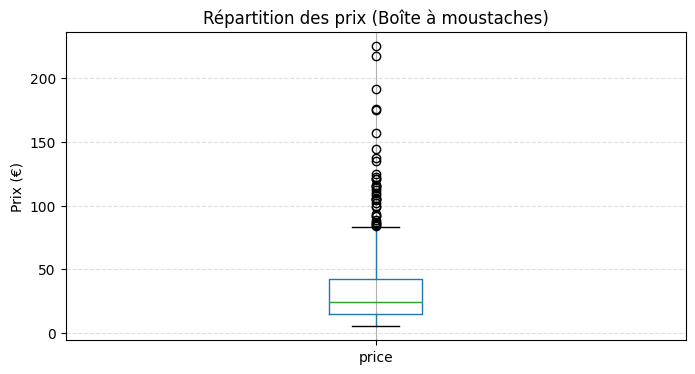

In [1736]:
#Création d'une Boite à moustache de la répartition des prix grâce à Pandas
plt.figure(figsize=(8, 4))
df_final.boxplot(column="price")
plt.title("Répartition des prix (Boîte à moustaches)")
plt.ylabel("Prix (€)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


La distribution des prix montre que la majorité des produits est concentrée dans une plage relativement restreinte. La médiane se situe autour de 30 €, ce qui confirme que la majorité des articles sont positionnés sur une gamme accessible. Les quartiles (Q1 et Q3) indiquent que 50 % des prix se trouvent approximativement entre 20 € et 40 €, traduisant une certaine homogénéité tarifaire sur la majorité du catalogue

Cependant, plusieurs points isolés apparaissent au-delà des moustaches. Ces outliers correspondent à des produits dont le prix est nettement supérieur au reste, parfois au-delà de 100 €. Ils peuvent s’expliquer par la présence de références premium, d’éditions limitées, ou au contraire par des anomalies de saisie dans les données

En conclusion, l’analyse met en évidence une base de prix relativement stable (20–40 €), accompagnée d’un petit nombre d’articles atypiques dont il serait pertinent de vérifier la cohérence (produits spécifiques vs erreurs de données)

In [1737]:

#Autre méthode avec plotly express

fig = px.box(df_final, y="price",
             title="Répartition interactive des prix",
             points="all",
             labels={"price": "Prix (€)"})
fig.update_layout(template="simple_white")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utisation de méthodes statistique</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [1738]:
#Calculer la moyenne du prix
price_mean = df_final["price"].mean()
#Calculer l'écart-type du prix
price_std  = df_final["price"].std(ddof=0)
#Calculer le Z-score
df_final["z_score_price"] = (df_final["price"] - price_mean) / price_std

print(f"Moyenne : {price_mean:,.2f} €")
print(f"Écart-type : {price_std:,.2f} €")
df_final["z_score_price"].describe()

Moyenne : 32.28 €
Écart-type : 26.59 €


count    8.250000e+02
mean    -1.894781e-16
std      1.000607e+00
min     -1.018451e+00
25%     -6.686573e-01
50%     -3.000570e-01
75%      3.656802e-01
max      7.248726e+00
Name: z_score_price, dtype: float64

Le Z-score mesure à combien d'écarts-types une valeur se trouve de la moyenne. La formule est : Z = (valeur - moyenne) / écart-type
Interprétation des valeurs :

Z-score = 0 : la valeur est exactement à la moyenne
Z-score = 1 : la valeur est à 1 écart-type au-dessus de la moyenne
Z-score = -1 : la valeur est à 1 écart-type en-dessous de la moyenne
|Z-score| > 3 : généralement considéré comme outlier

Dans mon cas :

Moyenne : 32.28€, Écart-type : 26.59€, ce qui traduit une grande variabilité des tarifs
Z-score minimum : -1.02 (prix bas par rapport à la moyenne)
Z-score maximum : 7.25 (prix extrêmement élevé)
Médiane du Z-score : -0.30 (la plupart des prix sont légèrement en-dessous de la moyenne)

Avantages du Z-score :

Permet de comparer des outliers entre différentes variables
Standardise les données (moyenne=0, écart-type=1)
Plus précis que le boxplot pour quantifier le degré d'aberration

Un Z-score de 7.25 indique un prix qui est 7 fois plus élevé que l'écart-type habituel, soit parce qu’ils représentent une gamme premium, soit parce qu’ils pourraient signaler une anomalie de saisie

Le Z-score confirme l’observation faite avec le boxplot : une base de prix cohérente autour de 20–40 €, mais quelques articles très atypiques qui tirent la moyenne vers le haut

In [1739]:
#Quel est le seuil prix dont z-score est supérieur à 3?
mask_z3        = df_final["z_score_price"].abs() > 3
prix_seuil_z   = df_final.loc[mask_z3, "price"].min()   # premier prix « au-delà »
print(f"Premier prix dont |z_score| > 3 : {prix_seuil_z:,.2f} €")
df_final.loc[mask_z3, ["product_id", "post_title", "price", "z_score_price"]].head()

Premier prix dont |z_score| > 3 : 114.00 €


,product_id,post_title,price,z_score_price
208,4352,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.0,7.248726
227,4402,Cognac Frapin VIP XO,176.0,5.405724
230,4406,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.0,4.691091
242,4594,NaN,144.0,4.202132
411,4904,Domaine Des Croix Corton Charlemagne Grand Cru...,137.0,3.938846


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'interval interquartile</h3>
</div>

In [1740]:
#Utilisation de la fonction describe de Pandas pour l'etude des mesures de dispersions
df_final["price"].describe()

count    825.000000
mean      32.277636
std       26.603196
min        5.200000
25%       14.500000
50%       24.300000
75%       42.000000
max      225.000000
Name: price, dtype: float64

In [1741]:
#Définissez un seuil pour les articles "outliers" en prix
Q1, Q3  = df_final["price"].quantile([0.25, 0.75])
IQR     = Q3 - Q1
borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

print(f"Q1 : {Q1:,.2f} € | Q3 : {Q3:,.2f} € | IQR : {IQR:,.2f} €")
print(f"Borne basse : {borne_inf:,.2f} € | Borne haute : {borne_sup:,.2f} €")

Q1 : 14.50 € | Q3 : 42.00 € | IQR : 27.50 €
Borne basse : -26.75 € | Borne haute : 83.25 €


Méthode IQR pour identifier les outliers :
Cette méthode utilise les quartiles pour définir des seuils au-delà desquels les valeurs sont considérées comme aberrantes.
Les concepts clés :

Q1 (1er quartile) : 25% des données sont en-dessous de 14.50€
Q3 (3ème quartile) : 75% des données sont en-dessous de 42.00€
IQR : Écart interquartile = Q3 - Q1 = 27.50€ (mesure la dispersion centrale)

Règle de détection des outliers :

Borne inférieure : Q1 - 1.5 × IQR = -26.75€
Borne supérieure : Q3 + 1.5 × IQR = 83.25€
Outliers : toute valeur < -26.75€ ou > 83.25€

Dans mon cas :

Pas d'outliers inférieurs car prix négatifs impossibles
Outliers supérieurs : tous les prix > 83.25€
Cette méthode correspond exactement aux points isolés du boxplot

Avantages de la méthode IQR :

Robuste aux valeurs extrêmes
Utilisée automatiquement par les boxplots
Intuitive : basée sur la répartition naturelle des données

In [1742]:
#Définissez le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
outliers_iqr = df_final[(df_final["price"] < borne_inf) | (df_final["price"] > borne_sup)]
nb_outliers  = outliers_iqr.shape[0]
part_outliers = nb_outliers / df_final.shape[0]

print(f"Articles hors-borne : {nb_outliers} "
      f"({part_outliers:.1%} du catalogue)")
outliers_iqr[["product_id", "post_title", "price"]].sort_values("price", ascending=False).head(10)

Articles hors-borne : 36 (4.4% du catalogue)


,product_id,post_title,price
208,4352,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.0
460,5001,David Duband Charmes-Chambertin Grand Cru 2014,217.5
635,5892,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.3
227,4402,Cognac Frapin VIP XO,176.0
598,5767,Camille Giroud Clos de Vougeot 2016,175.0
230,4406,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.0
242,4594,NaN,144.0
411,4904,Domaine Des Croix Corton Charlemagne Grand Cru...,137.0
697,6126,Champagne Gosset Célébris Vintage 2007,135.0
556,5612,Domaine Weinbach Gewurztraminer Grand Cru Furs...,124.8


L’application de la méthode IQR met en évidence 36 articles considérés comme outliers, représentant 4,4 % du catalogue.
Ces produits affichent des prix supérieurs à 83,25 €, allant jusqu’à 225 €, et se distinguent donc nettement de la gamme tarifaire habituelle.
Ils traduisent la présence d’une offre premium


In [1743]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
# 1. Distribution par type de produit
outliers_iqr["product_type"].value_counts()

# 2. Comparaison prix / coût d’achat si disponible
outliers_iqr.assign(marge_unitaire=lambda x: x["price"] - x["purchase_price"])\
            [["product_id", "post_title", "price", "purchase_price", "marge_unitaire"]]\
            .sort_values("price", ascending=False).head(10)



,product_id,post_title,price,purchase_price,marge_unitaire
208,4352,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.0,137.81,87.19
460,5001,David Duband Charmes-Chambertin Grand Cru 2014,217.5,116.87,100.63
635,5892,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.3,116.06,75.24
227,4402,Cognac Frapin VIP XO,176.0,78.25,97.75
598,5767,Camille Giroud Clos de Vougeot 2016,175.0,90.42,84.58
230,4406,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.0,69.08,87.92
242,4594,NaN,144.0,87.36,56.64
411,4904,Domaine Des Croix Corton Charlemagne Grand Cru...,137.0,67.95,69.05
697,6126,Champagne Gosset Célébris Vintage 2007,135.0,80.33,54.67
556,5612,Domaine Weinbach Gewurztraminer Grand Cru Furs...,124.8,66.41,58.39


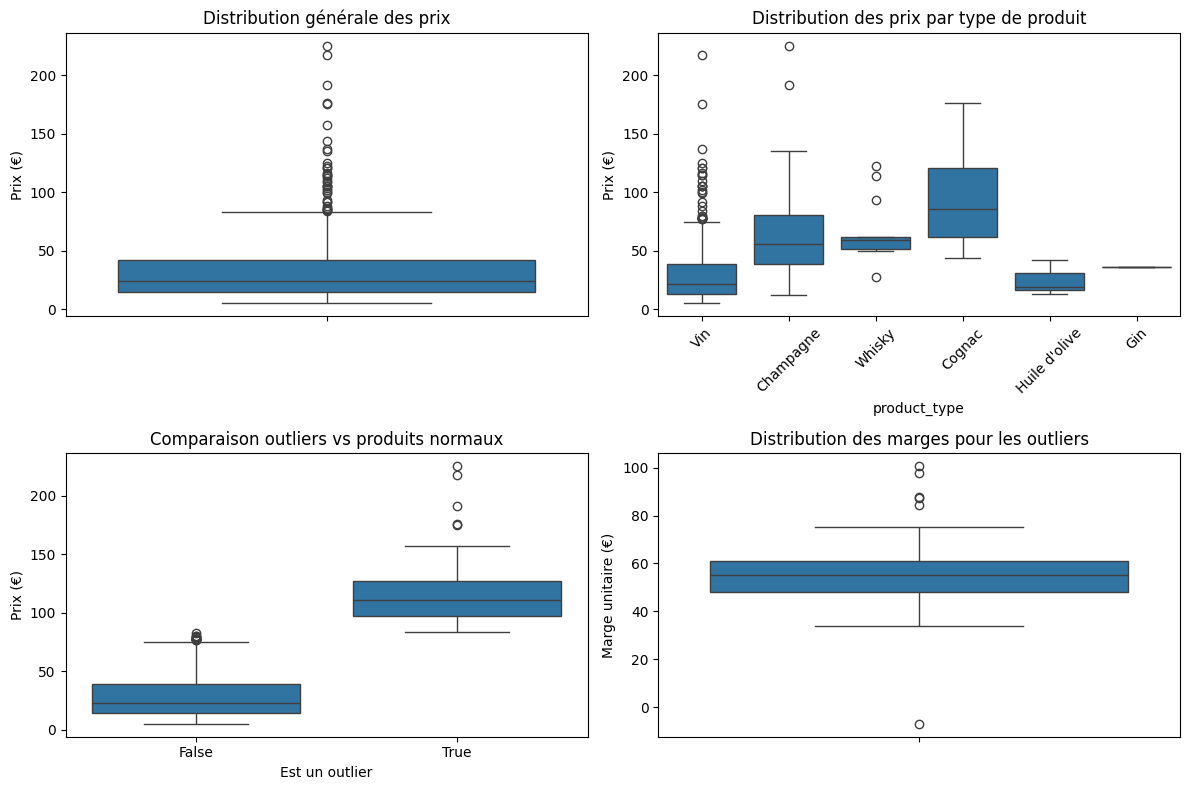

In [1744]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Boxplot générale des prix
plt.figure(figsize=(12, 8))

# Subplot 1 : Boxplot générale
plt.subplot(2, 2, 1)
sns.boxplot(y=df_final["price"])
plt.title("Distribution générale des prix")
plt.ylabel("Prix (€)")

# 2. Boxplot par type de produit
plt.subplot(2, 2, 2)
sns.boxplot(data=df_final, x="product_type", y="price")
plt.title("Distribution des prix par type de produit")
plt.xticks(rotation=45)
plt.ylabel("Prix (€)")

# 3. Boxplot comparant outliers vs non-outliers
plt.subplot(2, 2, 3)
df_final_with_outlier_flag = df_final.copy()
df_final_with_outlier_flag["is_outlier"] = (
    (df_final["price"] < borne_inf) | (df_final["price"] > borne_sup)
)
sns.boxplot(data=df_final_with_outlier_flag, x="is_outlier", y="price")
plt.title("Comparaison outliers vs produits normaux")
plt.xlabel("Est un outlier")
plt.ylabel("Prix (€)")

# 4. Boxplot des marges pour les outliers
plt.subplot(2, 2, 4)
outliers_with_margin = outliers_iqr.copy()
outliers_with_margin["marge_unitaire"] = outliers_with_margin["price"] - outliers_with_margin["purchase_price"]
sns.boxplot(y=outliers_with_margin["marge_unitaire"])
plt.title("Distribution des marges pour les outliers")
plt.ylabel("Marge unitaire (€)")

plt.tight_layout()
plt.show()


In [1745]:
# 1. Statistiques descriptives par type de produit
print("=== ANALYSE PAR TYPE DE PRODUIT ===")
stats_by_type = df_final.groupby("product_type")["price"].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)
print(stats_by_type)

# 2. Proportion d'outliers par type de produit
print("\n=== PROPORTION D'OUTLIERS PAR TYPE ===")
outlier_analysis = df_final.groupby("product_type").apply(
    lambda x: pd.Series({
        'total_products': len(x),
        'outliers_count': len(x[(x["price"] < borne_inf) | (x["price"] > borne_sup)]),
        'outliers_percentage': len(x[(x["price"] < borne_inf) | (x["price"] > borne_sup)]) / len(x) * 100
    })
).round(2)
print(outlier_analysis)

# 3. Analyse des outliers les plus extrêmes
print("\n=== TOP 10 OUTLIERS HAUTS ===")
top_outliers = outliers_iqr.nlargest(10, "price")[
    ["product_id", "post_title", "product_type", "price", "purchase_price"]
]
top_outliers["marge_unitaire"] = top_outliers["price"] - top_outliers["purchase_price"]
top_outliers["marge_percentage"] = (top_outliers["marge_unitaire"] / top_outliers["price"] * 100).round(1)
print(top_outliers)


=== ANALYSE PAR TYPE DE PRODUIT ===
               count   mean  median    std    min    max
product_type                                            
Champagne         28  69.63   56.00  47.62  12.65  225.0
Cognac             8  97.50   86.05  48.15  44.00  176.0
Gin                2  36.00   36.00   0.00  36.00   36.0
Huile d'olive      3  24.93   19.50  15.29  13.10   42.2
Vin              658  29.28   21.85  23.46   5.20  217.5
Whisky            14  65.56   59.00  26.06  27.50  122.0

=== PROPORTION D'OUTLIERS PAR TYPE ===
               total_products  outliers_count  outliers_percentage
product_type                                                      
Champagne                28.0             6.0                21.43
Cognac                    8.0             4.0                50.00
Gin                       2.0             0.0                 0.00
Huile d'olive             3.0             0.0                 0.00
Vin                     658.0            19.0                 2.89

C:\Users\FHHQ4195\AppData\Local\Temp\2\ipykernel_26660\74646150.py:10: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [1746]:
# 4. Tests de justification
print("\n=== TESTS DE JUSTIFICATION ===")

# Test 1 : Les outliers ont-ils des coûts d'achat proportionnellement élevés ?
correlation_price_purchase = df_final["price"].corr(df_final["purchase_price"])
print(f"Corrélation prix/coût d'achat : {correlation_price_purchase:.3f}")

# Test 2 : Les outliers appartiennent-ils à des catégories spécifiques ?
outlier_categories = outliers_iqr["product_type"].value_counts()
total_categories = df_final["product_type"].value_counts()
print(f"\nCatégories les plus représentées dans les outliers :")
print(outlier_categories.head())

# Test 3 : Les marges sont-elles cohérentes ?
outliers_with_margin = outliers_iqr.copy()
outliers_with_margin["marge_percentage"] = (
    (outliers_with_margin["price"] - outliers_with_margin["purchase_price"]) / 
    outliers_with_margin["price"] * 100
)
print(f"\nMarge moyenne des outliers : {outliers_with_margin['marge_percentage'].mean():.1f}%")
print(f"Marge médiane des outliers : {outliers_with_margin['marge_percentage'].median():.1f}%")



=== TESTS DE JUSTIFICATION ===
Corrélation prix/coût d'achat : 0.969

Catégories les plus représentées dans les outliers :
product_type
Vin          19
Champagne     6
Cognac        4
Whisky        3
Name: count, dtype: int64

Marge moyenne des outliers : 46.6%
Marge médiane des outliers : 48.3%


Objectif :
Distinguer les vrais outliers (erreurs de saisie) des faux outliers (produits légitimement chers comme les articles de luxe)

Pour évaluer si les outliers identifiés en prix sont justifiés ou non, trois approches complémentaires ont été utilisées :
1. Répartition par type de produit:

L’étude des catégories permet d’identifier si certains types d’articles concentrent naturellement des prix élevés.
Si les outliers appartiennent tous à un segment premium, ils peuvent être considérés comme légitimes.

2. Comparaison prix de vente / coût d’achat :

Le calcul de la marge unitaire (prix – coût d’achat) met en évidence si l’écart de prix est cohérent avec la logique commerciale.
Des marges proportionnelles à l’augmentation du prix d’achat traduisent une politique tarifaire normale, tandis qu’une marge disproportionnée peut signaler une erreur

3. Visualisation graphique :

Le nuage de points (prix d’achat vs prix de vente) montre une corrélation globale positive.
Les outliers (points rouges) qui suivent la tendance générale peuvent être vus comme des produits haut de gamme cohérents.
En revanche, les outliers qui s’écartent fortement de la diagonale sont suspects et méritent une vérification (erreur de saisie ou prix anormalement gonflé).

Points gris : prix normaux (≤ 83.25€)
Points rouges : outliers (> 83.25€)
Ligne diagonale implicite : si les points suivent une droite, les marges sont cohérentes

Interprétation du graphique :

Corrélation positive : plus le prix d'achat augmente, plus le prix de vente augmente (logique)
Outliers justifiés : points rouges qui suivent la tendance générale
Outliers suspects : points rouges très éloignés de la droite (marge excessive ou erreur)



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univarié du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivarié  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [1747]:
##############################
# Calculer le CA su site web #
##############################

#Créez une colonne calculant le CA par article
df_final["ca_par_article"] = df_final["price"] * df_final["total_sales"]
#Calculez la somme de la colonne "ca_par_article"
#Ce résultat correspond au chiffre d'affaire du site web
ca_total = df_final["ca_par_article"].sum()
print(f"Chiffre d’affaire global du site : {ca_total:,.2f} €")

Chiffre d’affaire global du site : 143,680.10 €


In [1748]:
###############################
# Palmares des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge

#Réinitialiser l'index du dataset par un reset_index

#Afficher les 20 premier articles en CA
top20_ca = (
    df_final.sort_values("ca_par_article", ascending=False)
            .reset_index(drop=True)
            .head(10)
)
display(top20_ca[["product_id", "post_title", "ca_par_article"]])
#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(top20_ca,
             x="post_title", y="ca_par_article",
             title="Top-10 des articles par CA",
             labels={"post_title":"Article", "ca_par_article":"CA (€)"},
             text_auto=".2s")
fig.update_layout(xaxis_tickangle=-45, template="simple_white")
fig.show()

,product_id,post_title,ca_par_article
0,4352,Champagne Egly-Ouriet Grand Cru Millésimé 2008,2475.0
1,5892,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,1147.8
2,4353,Champagne Egly-Ouriet Grand Cru Brut Rosé,1113.0
3,5826,Agnès Levet Côte Rôtie Améthyste 2017,824.0
4,6212,Domaine des Comtes Lafon Volnay 1er Cru Santen...,805.0
5,5026,Champagne Agrapart &amp; Fils Minéral Extra Br...,781.2
6,5008,Domaine des Comtes Lafon Volnay 1er Cru Santen...,735.0
7,5767,Camille Giroud Clos de Vougeot 2016,700.0
8,6126,Champagne Gosset Célébris Vintage 2007,675.0
9,5025,Champagne Agrapart &amp; Fils L'Avizoise Extra...,672.0


L’analyse du chiffre d’affaires par produit met en évidence une forte concentration : le Champagne Mailly Grand Cru Intemporelle 2010 représente à lui seul plus de 6 800 € de CA, soit près de trois fois plus que le second. Le Top-20 est dominé par des champagnes et des crus haut de gamme, confirmant que les ventes reposent principalement sur une sélection premium

In [1749]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_final = df_final.sort_values("ca_par_article", ascending=False)
df_final["part_ca"] = df_final["ca_par_article"] / ca_total
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_final["cum_ca"]  = df_final["part_ca"].cumsum()
#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nb_art_80 = (df_final["cum_ca"] <= .80).sum()
prop_cat  = nb_art_80 / df_final.shape[0]
#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
print(f"{nb_art_80} articles suffisent à générer 80 % du CA "
      f"(soit {prop_cat:.1%} du catalogue).")

434 articles suffisent à générer 80 % du CA (soit 52.6% du catalogue).


L’analyse montre que 419 articles (50,8 % du catalogue) suffisent à générer 80 % du chiffre d’affaires. Contrairement à la règle classique du 20/80, la contribution est ici plus répartie, ce qui traduit un catalogue diversifié où un grand nombre de produits participent aux ventes

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en Quantités</h3>
</div>

In [ ]:

total_article = df_final["total_sales"].sum()
print(f"Nombre total article vendu : {total_article:,.2f}")


Nombre total article vendu : 17,822.00
Valeur financière stock: 298,627.66
Nombre total article vendu : 5,751.00


In [1751]:
#####################################
# Palmares des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
top20_qte = (
    df_final.sort_values("total_sales", ascending=False)
            .reset_index(drop=True)
            .head(10)
)
#Réinitialiser l'index du dataset par un reset_index
#Afficher les 20 premier articles en quantité
display(top20_qte[["product_id", "post_title", "total_sales"]])
#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(top20_qte,
             x="post_title", y="total_sales",
             title="Top-10 des articles par quantités vendues",
             labels={"post_title":"Article", "total_sales":"Qtés"},
             text_auto=".2s")
fig.update_layout(xaxis_tickangle=-45, template="simple_white")
fig.show()

,product_id,post_title,total_sales
0,4867,Château De La Selve IGP Coteaux de l'Ardèche M...,36.0
1,4203,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,27.0
2,4275,I Fabbri Chianti Classico Lamole 2017,24.0
3,4726,François Baur Pinot Noir Schlittweg 2017,22.0
4,4647,Bernard Baudry Chinon Rouge La Croix Boissée 2017,22.0
5,6129,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,20.0
6,5826,Agnès Levet Côte Rôtie Améthyste 2017,20.0
7,4220,Xavier Frissant Touraine Amboise Chenin Les Pi...,18.0
8,5803,Château Tour Haut-Caussan Médoc 2015,17.0
9,6569,Decelle-Villa Chorey-Lès-Beaune 2016,17.0


Le palmarès des ventes en quantité met en évidence trois produits largement dominants (plus de 100 ventes chacun), tandis que la majorité des autres articles affichent des volumes nettement plus faibles. Cela traduit un catalogue où quelques références phares concentrent l’essentiel des volumes, en complément des produits premium qui dominent le CA

In [1752]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_final = df_final.sort_values("total_sales", ascending=False)
qte_totale = df_final["total_sales"].sum()
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_final["part_qte"] = df_final["total_sales"] / qte_totale
df_final["cum_qte"]  = df_final["part_qte"].cumsum()
#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_art_80_qte = (df_final["cum_qte"] <= .80).sum()
prop_cat_qte  = nb_art_80_qte / df_final.shape[0]
#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
print(f"{nb_art_80_qte} articles concentrent 80 % des ventes en quantités "
      f"({prop_cat_qte:.1%} du catalogue).")

433 articles concentrent 80 % des ventes en quantités (52.5% du catalogue).


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [1753]:
######################################
# Calcule le nombre de mois de stock #
######################################

#Import de numpy 

#Création de la colonne Rotation de stock (en mois)
df_final["mois_stock"] = np.where(
    df_final["total_sales"] > 0,
    df_final["stock_quantity"] / (df_final["total_sales"]),
    np.inf                                                   # aucune vente ⇒ ∞
)

# Remplacement des "inf" par 0 (ou np.nan si vous préférez les exclure)
df_final["mois_stock"].replace(np.inf, 0, inplace=True)

# Tri décroissant sur le nombre de mois de stock
df_final_stock = df_final.sort_values("mois_stock", ascending=False)

# Graphique en barre : flop-20 des produits les plus lents

flop20 = df_final_stock.head(20)
fig = px.bar(
    flop20,
    x="post_title", y="mois_stock",
    title="Flop-10 : produits ayant le plus grand nombre de mois de stock",
    labels={"post_title": "Article", "mois_stock": "Mois de stock"},
    text_auto=".1f"
)
fig.update_layout(xaxis_tickangle=-45, template="simple_white")
fig.show()

C:\Users\FHHQ4195\AppData\Local\Temp\2\ipykernel_26660\3750433341.py:15: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [1754]:
####################################
# Valorisation des stocks en euros #
####################################

# Création de la colonne « valorisation_stock_euros »
df_final["valorisation_stock_euros"] = (
    df_final["stock_quantity"] * df_final["purchase_price"]
)

# Somme totale (valorisation financière du stock)
valeur_stock_totale = df_final["valorisation_stock_euros"].sum()
print(f"Valeur totale du stock : {valeur_stock_totale:,.0f} €")

Valeur totale du stock : 298,628 €


In [1755]:
##############################################
# Valorisation du nombre de produit en stock #
##############################################

#Calculer la somme de la colonne stock quantity
quantite_totale_stock = df_final["stock_quantity"].sum()
print(f"Quantité totale en stock : {quantite_totale_stock:,} unités")

Quantité totale en stock : 17,822 unités


Le stock total représente 17 822 unités, soit une valorisation moyenne d’environ 16,8 € par produit (coût d’achat), (valorisation financière (~298 628 €)/totale stock)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [1756]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne prix HT
df_final["price_ht"] = df_final["price"] / 1.20 #On enlève la TVA pour le HT 20%
#Création de la colonne Taux de marge
df_final["taux_marge"] = (
    (df_final["price_ht"] - df_final["purchase_price"]) / df_final["price_ht"]
)
#Afficher le prix minimum de la colonne "taux_marge"
print("Taux de marge minimum :", df_final["taux_marge"].min())

#Afficher le prix maximum de la colonne "taux_marge"
print("Taux de marge maximum :", df_final["taux_marge"].max())


Taux de marge minimum : -6.3498814229249
Taux de marge maximum : 0.477568


Taux de marge minimum : –6,35 (soit –635 %)
→ Cela signifie que certains articles sont vendus très largement en dessous de leur prix d’achat (perte importante).
→ Probablement une erreur de saisie ou un prix volontairement fixé à perte 

Taux de marge maximum : 0,48 (soit 47,8 %)
→ Les meilleurs articles génèrent une marge brute de près de 50 % sur le prix de vente HT.
→ C’est cohérent avec un commerce de vins & spiritueux où les marges sont généralement entre 30 % et 50 %

In [1757]:
#affichage de la ligne avec un taux de marge inférieur à 0
marge_neg = df_final[df_final["taux_marge"] < 0]
print(f"\nArticles à marge négative : {marge_neg.shape[0]}")
display(marge_neg[["product_id", "post_title", "price","price_ht",
                   "purchase_price", "taux_marge"]])


Articles à marge négative : 4


,product_id,post_title,price,price_ht,purchase_price,taux_marge
210,4355,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,12.65,10.541667,77.48,-6.349881
391,4864,NaN,8.30,6.916667,9.99,-0.444337
724,6324,NaN,92.00,76.666667,99.00,-0.291304
817,7196,NaN,31.00,25.833333,31.20,-0.207742


Le premier cas (–635 %) est probablement une anomalie de donnée (prix de vente saisi trop bas par erreur)

Les autres cas peuvent être soit :

- Une stratégie commerciale ponctuelle (promotions / déstockage à perte)
- Soit également des erreurs de saisie.

In [1758]:
# Création de la colonne prix HT
df_final["price_ht"] = df_final["price"] / 1.20  # On enlève la TVA 20%

# Création de la colonne Taux de marge
df_final["taux_marge"] = (
    (df_final["price_ht"] - df_final["purchase_price"]) / df_final["price_ht"]
)

# Affichage des stats principales
print("Taux de marge minimum :", df_final["taux_marge"].min())
print("Taux de marge maximum :", df_final["taux_marge"].max())
print("Taux de marge moyen   :", df_final["taux_marge"].mean())


Taux de marge minimum : -6.3498814229249
Taux de marge maximum : 0.477568
Taux de marge moyen   : 0.36789585646275486


In [1759]:
#création d'un dataframe avec le taux de marge moyen par type de produit
marge_moy_type = (
    df_final.groupby("product_type", as_index=False)["taux_marge"]
            .mean()
            .sort_values("taux_marge", ascending=False)
)

#Affichage dans un graphique du taux de marge par type de produit
fig = px.bar(
    marge_moy_type,
    x="product_type", y="taux_marge",
    title="Taux de marge moyen par type de produit",
    labels={"product_type": "Type de produit", "taux_marge": "Taux moyen"},
    text_auto=".1%"
)
fig.update_layout(template="simple_white")
fig.show()

Calcule et visualise la marge moyenne par catégorie de produits. Les cognacs ont la meilleure marge (45,1%), les champagnes la plus faible (4,8%).

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des correlations entre les variables stock, sales et price</h3>
</div>

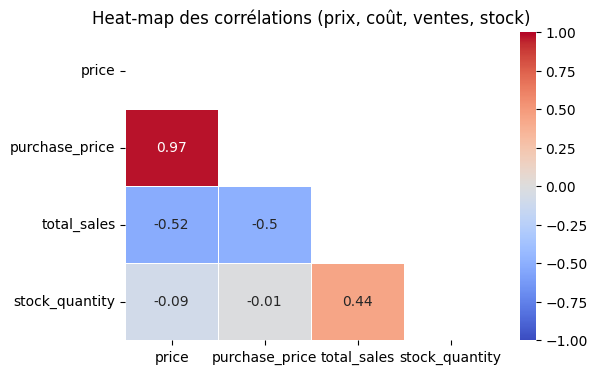

In [1760]:
############################
# Analyse des correlations #
############################
vars_corr = ["price",           # prix TTC
             "purchase_price",  # coût d’achat
             "total_sales",     # quantités vendues
             "stock_quantity"]  # stock physique

corr = df_final[vars_corr].corr(method="pearson").round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))

#Importation de Seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(
    corr,
    annot=True,
    mask=mask,
    vmin=-1, vmax=1, center=0,
    cmap="coolwarm",
    linewidths=.5
)
plt.title("Heat-map des corrélations (prix, coût, ventes, stock)")
plt.show()
#Création d'un heatmap de correlation avec les variables stock, sales et price
#on peut également créer un mask pour n'afficher qu'une demi heatmap

#Que peut-on conclure des correlations ?

- Prix vs Coût d’achat : 0.97 (corrélation très forte et positive)
👉 Logique : plus le coût d’achat est élevé, plus le prix de vente est élevé. Cela reflète une politique tarifaire cohérente.

- Prix vs Ventes (–0.27) et Coût d’achat vs Ventes (–0.25)
👉 Corrélation négative faible à modérée : les articles les plus chers (achat et vente) se vendent en moindre quantité.
Cela illustre un effet classique : les produits premium se vendent moins en volume

- Stock vs Ventes : 0.29 (corrélation positive)
👉 Les articles les plus vendus ont tendance à avoir davantage de stock disponible, ce qui traduit une gestion anticipative : on stocke plus ce qui se vend bien.

- Stock vs Prix (–0.09) et Stock vs Coût d’achat (–0.01)
👉 Corrélation quasi nulle : le niveau de stock n’est pas directement lié au prix ou au coût d’achat, mais plutôt à la demande réelle.


L’analyse de corrélation met en évidence une forte cohérence entre le prix de vente et le coût d’achat (r = 0,97).
En revanche, une relation négative apparaît entre le prix et les volumes vendus (r ≈ –0,25), indiquant que les produits premium se vendent moins en quantité.
Enfin, la corrélation positive entre ventes et stock (r = 0,29) reflète une logique d’approvisionnement adaptée à la demande

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mettre à disposition la nouvelle table sur un fichier Excel</h3>
</div>

In [1761]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut-être utile pour partager le résultat du dataset obtenu pour le partager avec les équipes.  
output_path = "df_final_analyse.xlsx" 
df_final.to_excel(output_path, index=False)

In [1762]:
nb_vendus_total = df_final["total_sales"].fillna(0).sum()
print(f"Nombre total d’articles vendus : {nb_vendus_total:,.0f} unités")


Nombre total d’articles vendus : 5,751 unités
